# Exercise 4.A Introduction to Linear Regression

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [9]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [10]:
print(f'\nSlope (coefficient):  {model.coef_[0]:.2f}')
print(f'Intercept:            {model.intercept_:.2f}')


Slope (coefficient):  4.10
Intercept:            47.68


In [11]:
y_pred = model.predict(X_test)

print('Actual scores:   ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:    [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [12]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


In [13]:
# measures the variance in exam scores so looms like a ridiculously good fit

C:\Users\BlakeC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


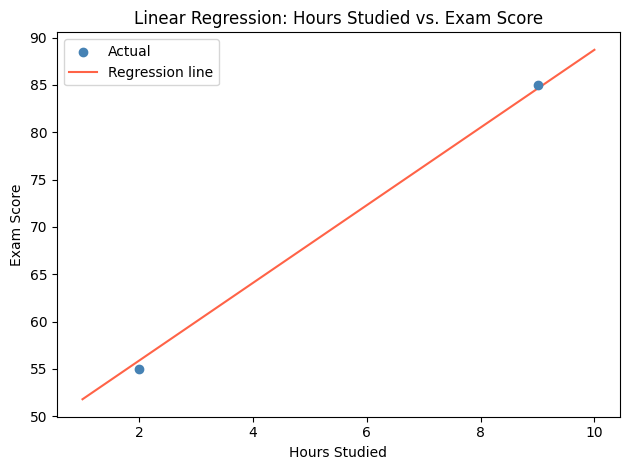

In [14]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

# Line: model predictions across the full range of X
x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100
).reshape(-1, 1)
y_line = model.predict(x_range)

plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# I mean yeah they are very close to the line bottom one being a bit further

## Lab 2
### Building your own model

In [16]:
adData = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    'monthly_revenue':  [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
                         12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 23800]
}
dfAds = pd.DataFrame(adData)
dfAds

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [17]:
X2 = dfAds[['monthly_ad_spend']]   # doubled up brackets -> DataFrame
y2 = dfAds['monthly_revenue']       # single (sad) bracket -> Series

print("shape of X2:", X2.shape)
print("shape of y2:", y2.shape)

shape of X2: (20, 1)
shape of y2: (20,)


In [18]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [19]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
print("Model trained successfully.")

Model trained successfully.


In [21]:
print(f'\nslope (coefficient):  {model2.coef_[0]:.2f}')
print(f'Intercept:            {model2.intercept_:.2f}')
#  “for each additional _dollar spent on ads_, the predicted __rev_ increases by _whatever the slope says_”)


slope (coefficient):  1.96
Intercept:            3625.89


 ### Making predictions and evaluating the model.

In [23]:
y2_pred = model2.predict(X2_test)

print("actual values:", list(y2_test))
print("predicted values:", [round(p, 2) for p in y2_pred])
#eh good enough

actual values: [4200, 21500, 19400, 5100]
predicted values: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [24]:
r2_score2 = model2.score(X2_test, y2_test)
print(f'R² score: {r2_score2:.3f}')

R² score: 0.998


In [26]:
#scratch that better than good enough 
#clearly we need to just put every single dollar into advertisements this ride could never possibly end or not be accounting for something we have never thought about


### Visualizing the results

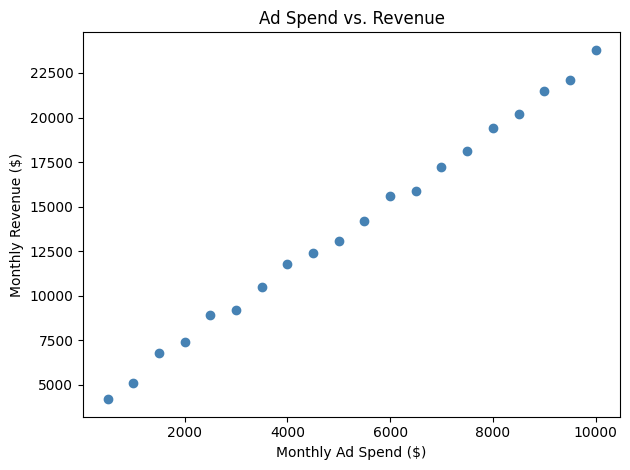

In [27]:
plt.scatter(dfAds['monthly_ad_spend'], dfAds['monthly_revenue'], color='steelblue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.tight_layout()
plt.show()

In [29]:
#it can only go up

 # buy buy buy 


C:\Users\BlakeC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


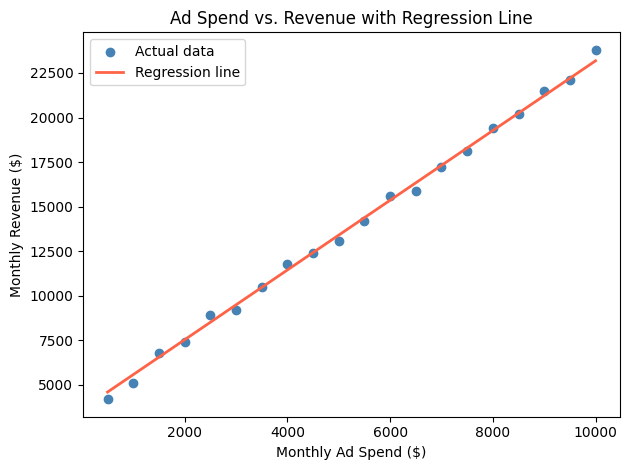

In [30]:
plt.scatter(dfAds['monthly_ad_spend'], dfAds['monthly_revenue'], color='steelblue', label='Actual data')

xRange = np.linspace(X2['monthly_ad_spend'].min(), X2['monthly_ad_spend'].max(), 100).reshape(-1, 1)
yLine = model2.predict(xRange)
plt.plot(xRange, yLine, color='tomato', linewidth=2, label='Regression line')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue with Regression Line')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# ok the error doesnt matter


In [3]:
# the line has further convinced me that the company will be sinking everything into the advertisement hole, costco be *darned* this advertising is good
# oh and yes the line does match what I expected from the R²

In [2]:
# to apologize for turning this in sunday night have this 
# https://www.youtube.com/watch?v=G45ptqdjclU
# (its only 3 minutes long)